# Un-primary-beam-corrected ALMA continuum contours on rotated JWST RGB images

Each continuum plane is restored from its primary-beam-corrected image as `PB-corrected image × primary beam`. The columns are Clump H6 (X3621), MSXDC G0.07 (X122), and AGAL 035.522-00.274 (X3819), with MIRI above NIRCam.

In [31]:
from pathlib import Path

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.stats import mad_std
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from matplotlib.image import imread
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse
from PIL import Image
from scipy.ndimage import binary_fill_holes, binary_propagation, gaussian_filter, label, map_coordinates

Image.MAX_IMAGE_PIXELS = None

REPO_DIR = Path('/Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows')
ALMA_DIR = Path('/Users/abarnes/Library/CloudStorage/Dropbox/Data/Galactic/JWST/cloud_h/alma')
JWST_DIR = Path('/Users/abarnes/Library/CloudStorage/Dropbox/Data/Galactic/JWST/cloud_h/jwst/fits/nanfilled/reprojected')
PLOT_DIR = REPO_DIR / 'plots'

MIRI_JPEG = JWST_DIR / 'miri_photoshop.jpeg'
MIRI_WCS_FITS = JWST_DIR / 'jw07230-o002_t003_miri_f770w_i2d_nanfilled_reprojected.fits'
NIRCAM_JPEG = JWST_DIR / 'nircam_photoshop.jpeg'
NIRCAM_WCS_FITS = JWST_DIR / 'jw07230-o004_t003_nircam_clear-f356w_i2d_nanfilled_reprojected.fits'

CONTINUUM_MAPS = [
    {
        'label': 'Clump H6 (X3621)',
        'band': 'ALMA Band 6',
        'fov_color': '#00ffff',
        'pb': ALMA_DIR / 'member.uid___A001_X3621_X2808.Clump_H6_sci.spw25_27_29_31_33_35_37_39_41_43.cont.I.pb.fits',
        'pbcor': ALMA_DIR / 'member.uid___A001_X3621_X2808.Clump_H6_sci.spw25_27_29_31_33_35_37_39_41_43.cont.I.pbcor.fits',
        'center': ('18h57m08.1279733251s', '+02d10m48.9612673891s'),
        'size_arcsec': 63.5302541379,
    },
    {
        'label': 'MSXDC G0.07 (X122)',
        'band': 'ALMA Band 7',
        'fov_color': '#ffcc00',
        'pb': ALMA_DIR / 'member.uid___A001_X122_X30d.MSXDC_G0_a_07_TE_X2599_X2210_cont_spw2.clean.flux.fits',
        'pbcor': ALMA_DIR / 'member.uid___A001_X122_X30d.MSXDC_G0_a_07_TE_X2599_X2210_cont_spw2.clean.image.pbcor.fits',
        'center': ('18h57m08.1279733251s', '+02d10m48.9612673891s'),
        'size_arcsec': 63.5302541379,
    },
    {
        'label': 'AGAL 035.522-00.274 (X3819)',
        'band': 'ALMA Band 6',
        'fov_color': '#ff66cc',
        'pb': ALMA_DIR / 'member.uid___A001_X3819_X177._035.522-00.274__sci.spw25_27_29_31.cont.I.pb.fits',
        'pbcor': ALMA_DIR / 'member.uid___A001_X3819_X177._035.522-00.274__sci.spw25_27_29_31.cont.I.selfcal.pbcor.fits',
        'center': ('18h57m08.2489822275s', '+02d10m50.6679897531s'),
        'size_arcsec': 26.6891258692,
        'smooth_sigma_pixels': 3.0,
    },
]

DISPLAY_PA_DEG = 354.80557109226515 - 360
MIRI_WHITE_THRESHOLD = 245
CONTOUR_MULTIPLES = np.array([2, 5, 10, 20], dtype=float)
MIN_CONTOUR_PIXELS = 20  # Remove closed above-level regions smaller than this.

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'


In [32]:
# Read the RGB JPEGs and their matching celestial WCS files.
# JPEG row 0 is at the top, unlike FITS/WCS y=0.
miri_rgb = np.flipud(imread(MIRI_JPEG)[..., :3]).copy()
nircam_rgb = np.flipud(imread(NIRCAM_JPEG)[..., :3])

with fits.open(MIRI_WCS_FITS, memmap=True) as hdul:
    miri_shape = hdul[1].data.shape
    miri_wcs = WCS(hdul[1].header).celestial
with fits.open(NIRCAM_WCS_FITS, memmap=True) as hdul:
    nircam_shape = hdul[1].data.shape
    nircam_wcs = WCS(hdul[1].header).celestial

if miri_rgb.shape[:2] != miri_shape:
    raise ValueError(f'MIRI JPEG shape {miri_rgb.shape[:2]} does not match FITS shape {miri_shape}.')
if nircam_rgb.shape[:2] != nircam_shape:
    raise ValueError(f'NIRCam JPEG shape {nircam_rgb.shape[:2]} does not match FITS shape {nircam_shape}.')

miri_white = np.all(miri_rgb >= MIRI_WHITE_THRESHOLD, axis=2)
miri_edge = np.zeros(miri_shape, dtype=bool)
miri_edge[[0, -1], :] = True
miri_edge[:, [0, -1]] = True
miri_rgb[binary_propagation(miri_edge & miri_white, mask=miri_white)] = 0
miri_pixel_scale = (np.mean(proj_plane_pixel_scales(miri_wcs)) * u.deg).to_value(u.arcsec)
print(f'MIRI display pixel scale: {miri_pixel_scale:.4f} arcsec/pixel')


MIRI display pixel scale: 0.1109 arcsec/pixel


Set DATE-AVG to '2026-04-20T19:13:48.581' from MJD-AVG.
Set DATE-END to '2026-04-20T20:21:51.119' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -19.247298 from OBSGEO-[XYZ].
Set OBSGEO-H to 1505726645.939 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2026-05-12T02:20:38.473' from MJD-AVG.
Set DATE-END to '2026-05-12T02:31:06.605' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.337902 from OBSGEO-[XYZ].
Set OBSGEO-H to 1674445997.841 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [33]:
def read_unprimary_beam_corrected(pb_path, pbcor_path):
    """Restore a continuum image as PB-corrected intensity times primary beam."""
    with fits.open(pb_path, memmap=True) as hdul:
        primary_beam = np.squeeze(hdul[0].data).astype(float)
        pb_wcs = WCS(hdul[0].header).celestial
    with fits.open(pbcor_path, memmap=True) as hdul:
        pbcor_image = np.squeeze(hdul[0].data).astype(float)
        pbcor_header = hdul[0].header.copy()
        pbcor_wcs = WCS(pbcor_header).celestial

    if primary_beam.ndim != 2 or pbcor_image.ndim != 2:
        raise ValueError(f'{pb_path.name} and {pbcor_path.name} must reduce to 2-D images.')
    if primary_beam.shape != pbcor_image.shape:
        raise ValueError(f'PB/PBCOR shape mismatch: {pb_path.name} and {pbcor_path.name}.')
    if not pb_wcs.wcs.compare(pbcor_wcs.wcs):
        raise ValueError(f'PB/PBCOR celestial WCS mismatch: {pb_path.name} and {pbcor_path.name}.')

    coverage = np.isfinite(primary_beam) & np.isfinite(pbcor_image)
    if not coverage.any():
        raise ValueError(f'{pb_path.name} and {pbcor_path.name} have no shared finite coverage.')
    continuum = np.full(primary_beam.shape, np.nan)
    continuum[coverage] = primary_beam[coverage] * pbcor_image[coverage]
    beam = {
        'major_arcsec': pbcor_header['BMAJ'] * 3600,
        'minor_arcsec': pbcor_header['BMIN'] * 3600,
        'pa_deg': pbcor_header['BPA'],
    }
    return continuum, pbcor_wcs, coverage, beam


def smooth_finite_data(data, sigma_pixels):
    """Gaussian-smooth finite pixels without spreading NaNs into the image."""
    valid = np.isfinite(data)
    weights = gaussian_filter(valid.astype(float), sigma=sigma_pixels)
    weighted_data = gaussian_filter(np.where(valid, data, 0.0), sigma=sigma_pixels)
    smoothed = np.full(data.shape, np.nan)
    smoothed[valid] = weighted_data[valid] / weights[valid]
    return smoothed


def make_rotated_wcs(center, size_arcsec):
    """Build a square rotated output WCS at the MIRI pixel scale."""
    display_center = SkyCoord(*center, frame='icrs')
    size_pixels = int(np.ceil(size_arcsec / miri_pixel_scale))
    rotation = np.deg2rad(DISPLAY_PA_DEG + 90)
    display_wcs = WCS(naxis=2)
    display_wcs.wcs.ctype = ['RA---TAN', 'DEC--TAN']
    display_wcs.wcs.cunit = ['deg', 'deg']
    display_wcs.wcs.crval = [display_center.ra.deg, display_center.dec.deg]
    display_wcs.wcs.crpix = [(size_pixels + 1) / 2, (size_pixels + 1) / 2]
    display_wcs.wcs.cdelt = [miri_pixel_scale / 3600, miri_pixel_scale / 3600]
    display_wcs.wcs.pc = np.array([[-1, 0], [0, 1]]) @ np.array([
        [np.cos(rotation), -np.sin(rotation)],
        [np.sin(rotation), np.cos(rotation)],
    ])
    display_wcs.wcs.set()
    return display_wcs, size_pixels


def sample_rgb(rgb, input_wcs, ra, dec):
    x, y = input_wcs.world_to_pixel_values(ra, dec)
    sampled = np.empty(ra.shape + (3,), dtype=rgb.dtype)
    for channel in range(3):
        sampled[..., channel] = map_coordinates(rgb[..., channel], [y, x], order=1, mode='constant', cval=0)
    return sampled


def sample_map(data, coverage, input_wcs, ra, dec):
    x, y = input_wcs.world_to_pixel_values(ra, dec)
    sampled_data = map_coordinates(data, [y, x], order=1, mode='constant', cval=np.nan)
    sampled_coverage = map_coordinates(coverage.astype(float), [y, x], order=0, mode='constant', cval=0)
    return sampled_data, sampled_coverage


def filter_small_contour_regions(data, coverage, levels, min_pixels):
    """Return one cleaned above-level mask per contour level."""
    valid = np.isfinite(data) & (coverage > 0.5)
    filtered_masks = []
    for level_value in levels:
        components, component_count = label(
            valid & (data >= level_value), structure=np.ones((3, 3), dtype=int)
        )
        pixel_counts = np.bincount(components.ravel())
        keep_component = pixel_counts >= min_pixels
        keep_component[0] = False
        filtered_mask = keep_component[components]
        removed_count = np.count_nonzero((pixel_counts[1:] > 0) & (pixel_counts[1:] < min_pixels))
        filtered_masks.append((level_value, filtered_mask, removed_count, component_count))
    return filtered_masks


Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keyword

Clump H6 (X3621): sigma=0.0001077, contour levels=[0.0002155  0.00053875 0.00107749 0.00215498], removed=[np.int64(211), np.int64(1), np.int64(1), np.int64(1)]
MSXDC G0.07 (X122): sigma=0.0001293, contour levels=[0.00025857 0.00064642 0.00129283 0.00258566], removed=[np.int64(22), np.int64(2), np.int64(0), np.int64(0)]
AGAL 035.522-00.274 (X3819): sigma=5.669e-05, contour levels=[0.00011339 0.00028346 0.00056693 0.00113386], removed=[np.int64(355), np.int64(4), np.int64(3), np.int64(2)]
Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/alma_continuum_unpbcor_contours_nircam_miri_rotated.pdf
Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/alma_continuum_unpbcor_contours_nircam_miri_rotated.png


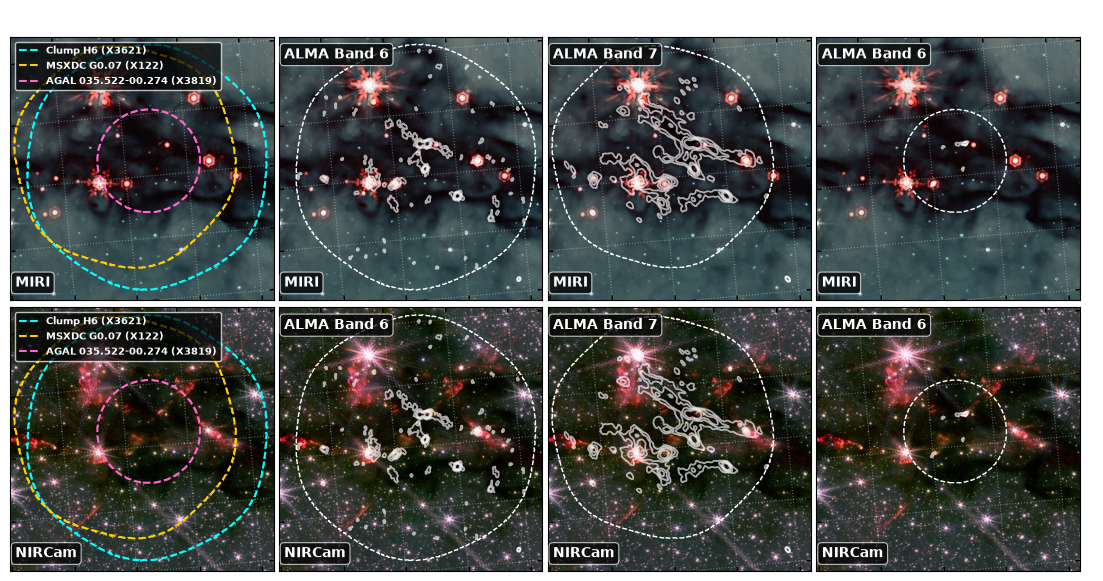

In [34]:
prepared_maps = []
for config in CONTINUUM_MAPS:
    continuum, continuum_wcs, coverage, beam = read_unprimary_beam_corrected(config['pb'], config['pbcor'])
    if 'smooth_sigma_pixels' in config:
        continuum = smooth_finite_data(continuum, config['smooth_sigma_pixels'])
    prepared_maps.append((config, continuum, continuum_wcs, coverage, beam))

fig = plt.figure(figsize=(11, 6))

# Left overview column: the large rotated field with all three ALMA footprints.
overview_wcs, overview_size = make_rotated_wcs(
    CONTINUUM_MAPS[0]['center'], CONTINUUM_MAPS[0]['size_arcsec']
)
overview_y, overview_x = np.mgrid[0:overview_size, 0:overview_size]
overview_ra, overview_dec = overview_wcs.pixel_to_world_values(overview_x, overview_y)
overview_images = (
    (sample_rgb(miri_rgb, miri_wcs, overview_ra, overview_dec), 'MIRI'),
    (sample_rgb(nircam_rgb, nircam_wcs, overview_ra, overview_dec), 'NIRCam'),
)
fov_handles = [
    Line2D([0], [0], color=config['fov_color'], linestyle='--', linewidth=1.5, label=config['label'])
    for config in CONTINUUM_MAPS
]

for row, (image, instrument) in enumerate(overview_images):
    ax = fig.add_subplot(2, 4, row * 4 + 1, projection=overview_wcs)
    ax.set_facecolor('black')
    ax.imshow(image, origin='lower')
    for config, continuum, continuum_wcs, coverage, beam in prepared_maps:
        _, overview_coverage = sample_map(
            continuum, coverage, continuum_wcs, overview_ra, overview_dec
        )
        ax.contour(
            overview_coverage, levels=[0.5], colors=[config['fov_color']],
            linestyles='--', linewidths=1.5,
        )
    ax.coords.grid(color='white', alpha=0.35, linestyle=':')
    ax.coords[0].set_ticklabel_visible(False)
    ax.coords[1].set_ticklabel_visible(False)
    ax.coords[0].set_axislabel('')
    ax.coords[1].set_axislabel('')
    ax.legend(
        handles=fov_handles, loc='upper left', facecolor='black', edgecolor='white',
        framealpha=0.72, labelcolor='white', fontsize=7,
    )
    ax.text(0.02, 0.04, instrument, transform=ax.transAxes, ha='left', va='bottom', fontsize=10, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.28', facecolor='black', edgecolor='white', linewidth=0.8, alpha=0.72))

# Three continuum-contour columns.
for column, (config, continuum, continuum_wcs, coverage, beam) in enumerate(prepared_maps, start=2):
    display_wcs = overview_wcs
    size_pixels = overview_size
    ra, dec = overview_ra, overview_dec

    display_miri = sample_rgb(miri_rgb, miri_wcs, ra, dec)
    display_nircam = sample_rgb(nircam_rgb, nircam_wcs, ra, dec)
    display_continuum, display_coverage = sample_map(continuum, coverage, continuum_wcs, ra, dec)

    contour_values = display_continuum[display_coverage > 0.5]
    sigma = mad_std(contour_values, ignore_nan=True)
    levels = CONTOUR_MULTIPLES * sigma
    filtered_contours = filter_small_contour_regions(
        display_continuum, display_coverage, levels, MIN_CONTOUR_PIXELS
    )
    removed_counts = [entry[2] for entry in filtered_contours]
    print(f"{config['label']}: sigma={sigma:.4g}, contour levels={levels}, removed={removed_counts}")

    for row, (image, instrument) in enumerate(((display_miri, 'MIRI'), (display_nircam, 'NIRCam'))):
        ax = fig.add_subplot(2, 4, row * 4 + column, projection=display_wcs)
        ax.set_facecolor('black')
        ax.imshow(image, origin='lower')
        for level_value, filtered_mask, removed_count, component_count in filtered_contours:
            if filtered_mask.any():
                ax.contour(filtered_mask.astype(float), levels=[0.5], colors='white', linewidths=1.25, alpha=0.65)
        ax.contour(display_coverage, levels=[0.5], colors='white', linestyles='--', linewidths=1.0)
        beam_patch = Ellipse(
            (0.91 * size_pixels, 0.08 * size_pixels),
            width=beam['major_arcsec'] / miri_pixel_scale,
            height=beam['minor_arcsec'] / miri_pixel_scale,
            angle=beam['pa_deg'] - DISPLAY_PA_DEG,
            facecolor='none', edgecolor='white', linewidth=1.5, alpha=0.9,
        )
        ax.add_patch(beam_patch)
        ax.coords.grid(color='white', alpha=0.35, linestyle=':')
        ax.coords[0].set_major_formatter('hh:mm:ss')
        ax.coords[1].set_major_formatter('dd:mm:ss')
        ax.coords[0].set_ticklabel_visible(False)
        ax.coords[1].set_ticklabel_visible(False)
        ax.coords[0].set_axislabel('')
        ax.coords[1].set_axislabel('')
        if row == 0:
            ax.set_title(config['label'], fontsize=12, fontweight='bold', color='white', pad=10)
        ax.text(0.02, 0.96, config['band'], transform=ax.transAxes, ha='left', va='top', fontsize=10, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.28', facecolor='black', edgecolor='white', linewidth=0.8, alpha=0.72))
        ax.text(0.02, 0.04, instrument, transform=ax.transAxes, ha='left', va='bottom', fontsize=10, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.28', facecolor='black', edgecolor='white', linewidth=0.8, alpha=0.72))

fig.tight_layout()
fig.subplots_adjust(wspace=0.02, hspace=-0.05)
for extension in ('pdf', 'png'):
    output_path = PLOT_DIR / f'alma_continuum_unpbcor_contours_nircam_miri_rotated.{extension}'
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f'Saved {output_path}')
plt.show()


Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/alma_continuum_unpbcor_contours_nircam_miri_rotated_no_overview.pdf
Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/alma_continuum_unpbcor_contours_nircam_miri_rotated_no_overview.png


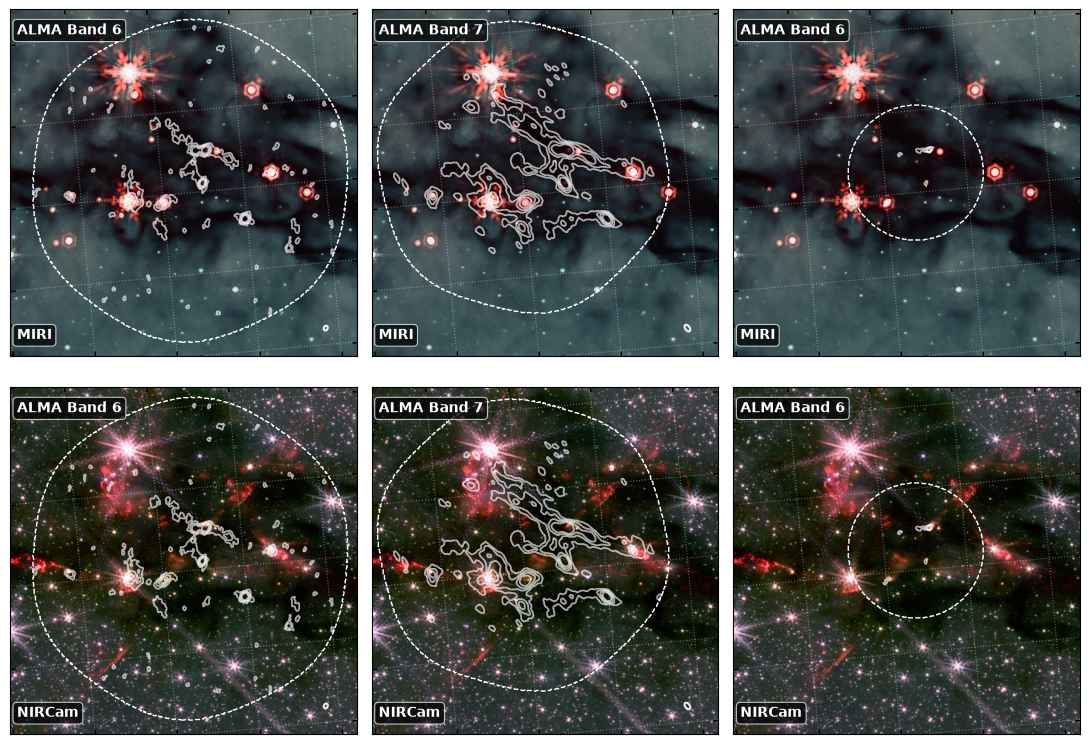

In [35]:
# Make a second version containing only the three continuum columns.
fig_no_overview = plt.figure(figsize=(11, 8))

for column, (config, continuum, continuum_wcs, coverage, beam) in enumerate(prepared_maps, start=1):
    display_wcs = overview_wcs
    size_pixels = overview_size
    ra, dec = overview_ra, overview_dec

    display_miri = sample_rgb(miri_rgb, miri_wcs, ra, dec)
    display_nircam = sample_rgb(nircam_rgb, nircam_wcs, ra, dec)
    display_continuum, display_coverage = sample_map(continuum, coverage, continuum_wcs, ra, dec)

    contour_values = display_continuum[display_coverage > 0.5]
    sigma = mad_std(contour_values, ignore_nan=True)
    levels = CONTOUR_MULTIPLES * sigma
    filtered_contours = filter_small_contour_regions(
        display_continuum, display_coverage, levels, MIN_CONTOUR_PIXELS
    )

    for row, (image, instrument) in enumerate(((display_miri, 'MIRI'), (display_nircam, 'NIRCam'))):
        ax = fig_no_overview.add_subplot(2, 3, row * 3 + column, projection=display_wcs)
        ax.set_facecolor('black')
        ax.imshow(image, origin='lower')
        for level_value, filtered_mask, removed_count, component_count in filtered_contours:
            if filtered_mask.any():
                ax.contour(filtered_mask.astype(float), levels=[0.5], colors='white', linewidths=1.25, alpha=0.65)
        ax.contour(display_coverage, levels=[0.5], colors='white', linestyles='--', linewidths=1.0)
        beam_patch = Ellipse(
            (0.91 * size_pixels, 0.08 * size_pixels),
            width=beam['major_arcsec'] / miri_pixel_scale,
            height=beam['minor_arcsec'] / miri_pixel_scale,
            angle=beam['pa_deg'] - DISPLAY_PA_DEG,
            facecolor='none', edgecolor='white', linewidth=1.5, alpha=0.9,
        )
        ax.add_patch(beam_patch)
        ax.coords.grid(color='white', alpha=0.35, linestyle=':')
        ax.coords[0].set_ticklabel_visible(False)
        ax.coords[1].set_ticklabel_visible(False)
        ax.coords[0].set_axislabel('')
        ax.coords[1].set_axislabel('')
        ax.text(0.02, 0.96, config['band'], transform=ax.transAxes, ha='left', va='top', fontsize=10, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.28', facecolor='black', edgecolor='white', linewidth=0.8, alpha=0.72))
        ax.text(0.02, 0.04, instrument, transform=ax.transAxes, ha='left', va='bottom', fontsize=10, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.28', facecolor='black', edgecolor='white', linewidth=0.8, alpha=0.72))

fig_no_overview.tight_layout()
# fig_no_overview.subplots_adjust(wspace=0.02, hspace=-0.05)
for extension in ('pdf', 'png'):
    output_path = PLOT_DIR / f'alma_continuum_unpbcor_contours_nircam_miri_rotated_no_overview.{extension}'
    fig_no_overview.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f'Saved {output_path}')
plt.show()


Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/alma_continuum_unpbcor_contours_nircam_miri_rotated_individual_fov.pdf
Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/alma_continuum_unpbcor_contours_nircam_miri_rotated_individual_fov.png


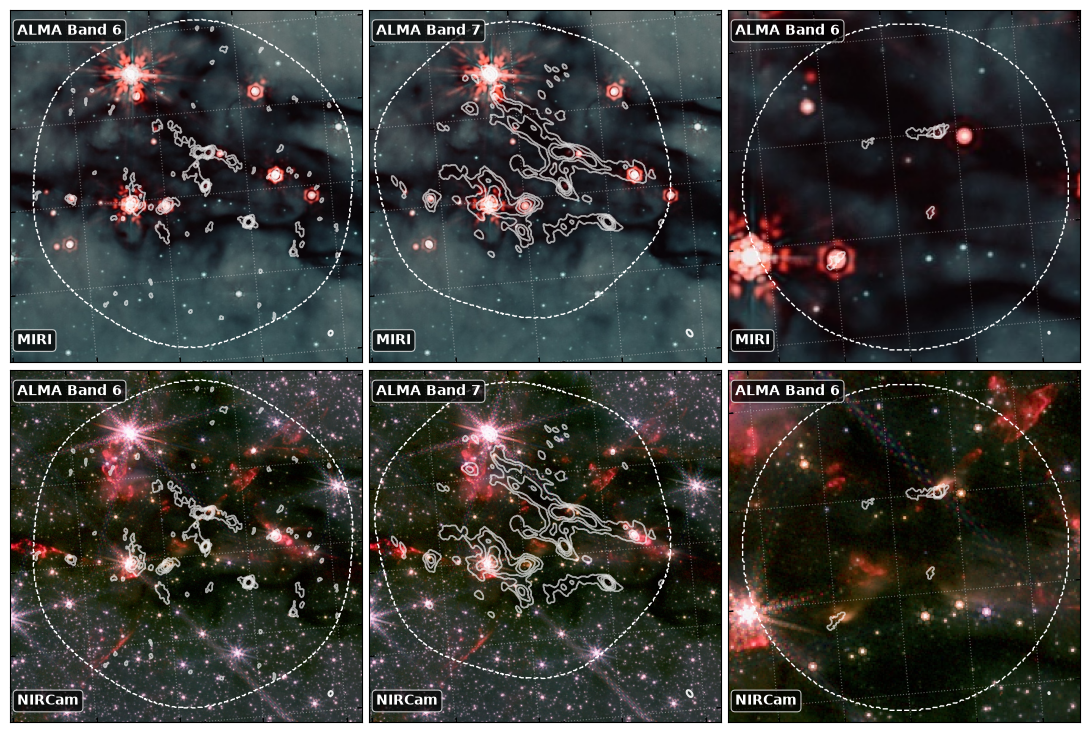

In [40]:
# Make a third version in which each column uses its configured field of view.
fig_individual_fov = plt.figure(figsize=(11, 8))

for column, (config, continuum, continuum_wcs, coverage, beam) in enumerate(prepared_maps, start=1):
    display_wcs, size_pixels = make_rotated_wcs(config['center'], config['size_arcsec'])
    display_y, display_x = np.mgrid[0:size_pixels, 0:size_pixels]
    ra, dec = display_wcs.pixel_to_world_values(display_x, display_y)

    display_miri = sample_rgb(miri_rgb, miri_wcs, ra, dec)
    display_nircam = sample_rgb(nircam_rgb, nircam_wcs, ra, dec)
    display_continuum, display_coverage = sample_map(continuum, coverage, continuum_wcs, ra, dec)

    contour_values = display_continuum[display_coverage > 0.5]
    sigma = mad_std(contour_values, ignore_nan=True)
    levels = CONTOUR_MULTIPLES * sigma
    filtered_contours = filter_small_contour_regions(
        display_continuum, display_coverage, levels, MIN_CONTOUR_PIXELS
    )

    for row, (image, instrument) in enumerate(((display_miri, 'MIRI'), (display_nircam, 'NIRCam'))):
        ax = fig_individual_fov.add_subplot(2, 3, row * 3 + column, projection=display_wcs)
        ax.set_facecolor('black')
        ax.imshow(image, origin='lower')
        for level_value, filtered_mask, removed_count, component_count in filtered_contours:
            if filtered_mask.any():
                ax.contour(filtered_mask.astype(float), levels=[0.5], colors='white', linewidths=1.25, alpha=0.65)
        ax.contour(display_coverage, levels=[0.5], colors='white', linestyles='--', linewidths=1.0)
        beam_patch = Ellipse(
            (0.91 * size_pixels, 0.08 * size_pixels),
            width=beam['major_arcsec'] / miri_pixel_scale,
            height=beam['minor_arcsec'] / miri_pixel_scale,
            angle=beam['pa_deg'] - DISPLAY_PA_DEG,
            facecolor='none', edgecolor='white', linewidth=1.5, alpha=0.9,
        )
        ax.add_patch(beam_patch)
        ax.coords.grid(color='white', alpha=0.35, linestyle=':')
        ax.coords[0].set_ticklabel_visible(False)
        ax.coords[1].set_ticklabel_visible(False)
        ax.coords[0].set_axislabel('')
        ax.coords[1].set_axislabel('')
        ax.text(0.02, 0.96, config['band'], transform=ax.transAxes, ha='left', va='top', fontsize=10, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.28', facecolor='black', edgecolor='white', linewidth=0.8, alpha=0.72))
        ax.text(0.02, 0.04, instrument, transform=ax.transAxes, ha='left', va='bottom', fontsize=10, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.28', facecolor='black', edgecolor='white', linewidth=0.8, alpha=0.72))

fig_individual_fov.tight_layout()
fig_individual_fov.subplots_adjust(wspace=0.02, hspace=-0.12)
for extension in ('pdf', 'png'):
    output_path = PLOT_DIR / f'alma_continuum_unpbcor_contours_nircam_miri_rotated_individual_fov.{extension}'
    fig_individual_fov.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f'Saved {output_path}')
plt.show()
